In [158]:
using Plots
using LinearAlgebra
using NPZ
include("../alpcahFamily.jl")
include("../helperFunctions.jl")

heppcatWrapper_known (generic function with 1 method)

In [159]:
X = npzread("X.npy")
labels = npzread("labels.npy");
# print size of X
println("Size of X: ", size(X))

Size of X: (281, 132, 272)


In [160]:
# node = 247
# X = X[:,:,node]
# reshape X to comnbine last two dims
X = reshape(X, size(X,1), size(X,2)*size(X,3));

In [161]:
# permute dims of X
X = permutedims(X, (2, 1))

35904×281 Matrix{Float32}:
 5.41611  13.5891    8.69801  9.60316  …   9.30682  25.4426   22.2649
 6.7878   12.6205   11.5588   9.26001      7.67059  17.5962   22.3965
 6.52232  12.5496    9.99734  8.41444      7.70009  21.8261   12.9034
 3.65948  12.0926   13.7242   9.36138      7.25224  16.9329   13.1233
 3.26724  10.1976    7.5267   8.52993      4.94417  17.5472   18.5025
 8.26626  10.4583    5.848    7.49968  …   4.04408  15.6037   17.8259
 4.03347  10.6975   16.4409   8.74456      3.75285  17.2377   18.7969
 4.94457  10.316     7.20236  7.14702     10.214    13.9842   16.3343
 6.10081   9.12051   9.75218  8.79409      9.70749   7.40603  12.681
 5.0763   10.2624    7.45558  4.84482      6.3156   15.428     4.27335
 6.24013   8.96456  12.2733   8.22492  …   8.15787  15.4507   11.1874
 5.53801   7.18558   9.61839  7.89125      9.39281   9.35932   9.62883
 4.77885   6.86617   5.56357  6.30955      6.79015   8.82736   8.51523
 ⋮                                     ⋱                     

In [162]:
estimateRank(X; rankMethod=:flippa)

1

In [163]:
U = LR_ALPCAH(X, 1; alpcahIter=100)
variances = grouplessVarianceUpdate(X, U*U'*X);

In [164]:
# plot boxplots showing variances vector info for each label group in labels so x axis is label group and y axis is variance value
using StatsPlots
groupedVariances = Dict()
for label in unique(labels)
    groupedVariances[label] = variances[labels .== label]
end 

In [165]:
groupedVariances

Dict{Any, Any} with 3 entries:
  0.0 => [1.47014, 3.03401, 2.62549, 2.11221, 2.30765, 2.86647, 2.17508, 1.8062…
  2.0 => [2.6272, 2.05456, 2.009, 2.76803, 2.07395, 2.18227, 1.44406, 2.54603, …
  1.0 => [1.95218, 2.24796, 2.14668, 2.54736, 2.12901, 2.77655, 2.16002, 2.3115…

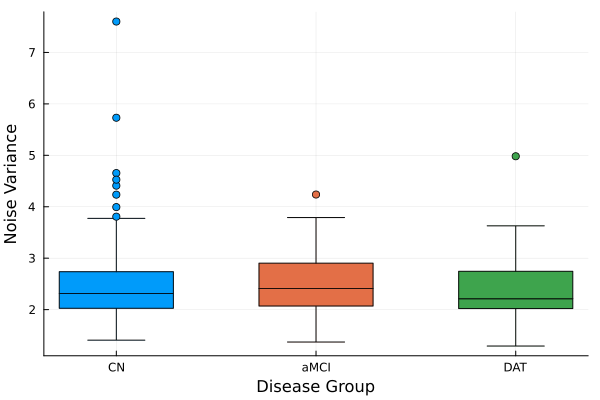

In [168]:
boxplot(["CN" "aMCI" "DAT"], [groupedVariances[0], groupedVariances[1], groupedVariances[2]], xlabel="Disease Group", ylabel="Noise Variance", legend=false)
# save figure
#savefig("variance_boxplot.png")